# TASK 6: NEURAL COLLABORATIVE FILTERING (NCF)

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

# Deep Learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
print("TASK 6: NEURAL COLLABORATIVE FILTERING (NCF)")

print(f"\nTensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU available: {len(gpus)} GPU(s)")
else:
    print("No GPU found, training sẽ dùng CPU (chậm hơn)")

TASK 6: NEURAL COLLABORATIVE FILTERING (NCF)

TensorFlow version: 2.20.0
Keras version: 3.12.0
No GPU found, training sẽ dùng CPU (chậm hơn)


## CHUẨN BỊ DỮ LIỆU

In [2]:
print("CHUẨN BỊ DỮ LIỆU")
# Load cleaned data
print("\nĐang load dữ liệu...")
ratings = pd.read_csv('../data/cleaned/ratings_cleaned.csv')
movies = pd.read_csv('../data/cleaned/movies_cleaned.csv')

print(f"Đã load ratings: {len(ratings):,} đánh giá")
print(f"Đã load movies: {len(movies):,} bộ phim")

print(f"\nThống kê:")
print(f"   - Số users: {ratings['userId'].nunique():,}")
print(f"   - Số movies: {ratings['movieId'].nunique():,}")
print(f"   - Rating range: {ratings['rating'].min():.1f} - {ratings['rating'].max():.1f}")

# Convert userId và movieId thành indices (0, 1, 2, ...)
print("\nĐang convert IDs thành indices...")

user_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

ratings['user_idx'] = user_encoder.fit_transform(ratings['userId'])
ratings['movie_idx'] = movie_encoder.fit_transform(ratings['movieId'])

n_users = ratings['user_idx'].nunique()
n_movies = ratings['movie_idx'].nunique()

print(f"User indices: 0 → {n_users - 1} ({n_users:,} users)")
print(f"Movie indices: 0 → {n_movies - 1} ({n_movies:,} movies)")

# Normalize ratings về [0, 1] cho neural network
print("\nĐang normalize ratings về [0, 1]...")
ratings['rating_normalized'] = (ratings['rating'] - 1) / 4  # [1,5] → [0,1]
print(f"Rating normalized range: {ratings['rating_normalized'].min():.2f} - {ratings['rating_normalized'].max():.2f}")

# Create training data
print("\nĐang tạo training pairs...")
X_user = ratings['user_idx'].values
X_movie = ratings['movie_idx'].values
y = ratings['rating_normalized'].values

print(f"X_user shape: {X_user.shape}")
print(f"X_movie shape: {X_movie.shape}")
print(f"y shape: {y.shape}")

# Split train/validation/test (70/15/15)
print("\nĐang split train/validation/test (70/15/15)...")

X_train_user, X_temp_user, X_train_movie, X_temp_movie, y_train, y_temp = train_test_split(
    X_user, X_movie, y, test_size=0.3, random_state=42
)

X_val_user, X_test_user, X_val_movie, X_test_movie, y_val, y_test = train_test_split(
    X_temp_user, X_temp_movie, y_temp, test_size=0.5, random_state=42
)

print(f"Train set: {len(X_train_user):,} samples ({len(X_train_user)/len(X_user)*100:.1f}%)")
print(f"Validation set: {len(X_val_user):,} samples ({len(X_val_user)/len(X_user)*100:.1f}%)")
print(f"Test set: {len(X_test_user):,} samples ({len(X_test_user)/len(X_user)*100:.1f}%)")


CHUẨN BỊ DỮ LIỆU

Đang load dữ liệu...
Đã load ratings: 1,000,209 đánh giá
Đã load movies: 3,416 bộ phim

Thống kê:
   - Số users: 6,040
   - Số movies: 3,706
   - Rating range: 1.0 - 5.0

Đang convert IDs thành indices...
User indices: 0 → 6039 (6,040 users)
Movie indices: 0 → 3705 (3,706 movies)

Đang normalize ratings về [0, 1]...
Rating normalized range: 0.00 - 1.00

Đang tạo training pairs...
X_user shape: (1000209,)
X_movie shape: (1000209,)
y shape: (1000209,)

Đang split train/validation/test (70/15/15)...
Train set: 700,146 samples (70.0%)
Validation set: 150,031 samples (15.0%)
Test set: 150,032 samples (15.0%)


## XÂY DỰNG NEURAL NETWORK

In [3]:
print("XÂY DỰNG NEURAL NETWORK")

print("\nĐang xây dựng model architecture...")

# Hyperparameters
EMBEDDING_DIM = 50
DENSE_UNITS = [256, 128, 64]

print(f"\nHyperparameters:")
print(f"   - Embedding dimension: {EMBEDDING_DIM}")
print(f"   - Dense layers: {' → '.join(map(str, DENSE_UNITS))}")
print(f"   - Output activation: linear (để predict continuous rating)")
print(f"   - Loss function: MSE")
print(f"   - Optimizer: Adam")

# Input layers
user_input = layers.Input(shape=(1,), name='user_input')
movie_input = layers.Input(shape=(1,), name='movie_input')

# Embedding layers
user_embedding = layers.Embedding(
    input_dim=n_users,
    output_dim=EMBEDDING_DIM,
    name='user_embedding'
)(user_input)
user_vec = layers.Flatten(name='user_flatten')(user_embedding)

movie_embedding = layers.Embedding(
    input_dim=n_movies,
    output_dim=EMBEDDING_DIM,
    name='movie_embedding'
)(movie_input)
movie_vec = layers.Flatten(name='movie_flatten')(movie_embedding)

# Concatenate user and movie embeddings
concat = layers.Concatenate(name='concat')([user_vec, movie_vec])

# Dense layers với Dropout
x = layers.Dense(DENSE_UNITS[0], activation='relu', name='dense_1')(concat)
x = layers.Dropout(0.3, name='dropout_1')(x)

x = layers.Dense(DENSE_UNITS[1], activation='relu', name='dense_2')(x)
x = layers.Dropout(0.3, name='dropout_2')(x)

x = layers.Dense(DENSE_UNITS[2], activation='relu', name='dense_3')(x)
x = layers.Dropout(0.2, name='dropout_3')(x)

# Output layer (linear activation cho regression)
output = layers.Dense(1, activation='linear', name='output')(x)

# Build model
model = models.Model(inputs=[user_input, movie_input], outputs=output, name='NCF_Model')

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\nModel architecture:")
model.summary()

# Calculate total parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")

XÂY DỰNG NEURAL NETWORK

Đang xây dựng model architecture...

Hyperparameters:
   - Embedding dimension: 50
   - Dense layers: 256 → 128 → 64
   - Output activation: linear (để predict continuous rating)
   - Loss function: MSE
   - Optimizer: Adam

Model architecture:


Model: "NCF_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ movie_input (InputLayer)      │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ user_embedding (Embedding)    │ (None, 1, 50)             │         302,000 │ user_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ movie_embedding (Embedding)   │ (None, 1, 50)             │         185,300 │ movie_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ user_flatten (Flatten)        │ (None, 50)                │               0 │ user_embedding[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ movie_flatten (Flatten)       │ (None, 50)                │               0 │ movie_embedding[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concat (Concatenate)          │ (None, 100)               │               0 │ user_flatten[0][0],        │
│                               │                           │                 │ movie_flatten[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 256)               │          25,856 │ concat[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 256)               │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 128)               │          32,896 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 128)               │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 64)                │           8,256 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 64)                │               0 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output (Dense)                │ (None, 1)                 │              65 │ dropout_3[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 554,373 (2.11 MB)

 Trainable params: 554,373 (2.11 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 554,373


## TRAIN MODEL

In [4]:
print("TRAIN MODEL")

print("\nTraining configuration:")
EPOCHS = 20
BATCH_SIZE = 256
print(f"   - Epochs: {EPOCHS}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Steps per epoch: {len(X_train_user) // BATCH_SIZE}")

# Callbacks
print("\nĐang setup callbacks...")

# EarlyStopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)
print("EarlyStopping: patience=3")

# ModelCheckpoint
checkpoint = callbacks.ModelCheckpoint(
    '../models/neural_cf_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
print("ModelCheckpoint: save best model")

# ReduceLROnPlateau
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)
print("ReduceLROnPlateau: factor=0.5, patience=2")

# Train model
print("\nĐang train model...")
print("   (Có thể mất 5-15 phút tùy hardware...)\n")

history = model.fit(
    [X_train_user, X_train_movie],
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=([X_val_user, X_val_movie], y_val),
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("\nTraining hoàn tất!")


TRAIN MODEL

Training configuration:
   - Epochs: 20
   - Batch size: 256
   - Steps per epoch: 2734

Đang setup callbacks...
EarlyStopping: patience=3
ModelCheckpoint: save best model
ReduceLROnPlateau: factor=0.5, patience=2

Đang train model...
   (Có thể mất 5-15 phút tùy hardware...)

Epoch 1/20
2730/2735 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0731 - mae: 0.2125
Epoch 1: val_loss improved from None to 0.05243, saving model to ../models/neural_cf_model.h5


2735/2735 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 0.0601 - mae: 0.1947 - val_loss: 0.0524 - val_mae: 0.1828 - learning_rate: 0.0010
Epoch 2/20
2731/2735 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0518 - mae: 0.1799
Epoch 2: val_loss improved from 0.05243 to 0.05083, saving model to ../models/neural_cf_model.h5


2735/2735 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 0.0517 - mae: 0.1797 - val_loss: 0.0508 - val_mae: 0.1778 - learning_rate: 0.0010
Epoch 3/20
2732/2735 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0492 - mae: 0.1748
Epoch 3: val_loss improved from 0.05083 to 0.04994, saving model to ../models/neural_cf_model.h5


2735/2735 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 0.0493 - mae: 0.1750 - val_loss: 0.0499 - val_mae: 0.1758 - learning_rate: 0.0010
Epoch 4/20
2731/2735 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0471 - mae: 0.1710
Epoch 4: val_loss improved from 0.04994 to 0.04939, saving model to ../models/neural_cf_model.h5


2735/2735 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 0.0475 - mae: 0.1718 - val_loss: 0.0494 - val_mae: 0.1751 - learning_rate: 0.0010
Epoch 5/20
2731/2735 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0452 - mae: 0.1673
Epoch 5: val_loss improved from 0.04939 to 0.04870, saving model to ../models/neural_cf_model.h5


2735/2735 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 0.0457 - mae: 0.1684 - val_loss: 0.0487 - val_mae: 0.1745 - learning_rate: 0.0010
Epoch 6/20
2733/2735 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0430 - mae: 0.1631
Epoch 6: val_loss improved from 0.04870 to 0.04854, saving model to ../models/neural_cf_model.h5


2735/2735 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 0.0437 - mae: 0.1645 - val_loss: 0.0485 - val_mae: 0.1734 - learning_rate: 0.0010
Epoch 7/20
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0411 - mae: 0.1596
Epoch 7: val_loss did not improve from 0.04854
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0420 - mae: 0.1613 - val_loss: 0.0490 - val_mae: 0.1747 - learning_rate: 0.0010
Epoch 8/20
2729/2735 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0396 - mae: 0.1567
Epoch 8: val_loss did not improve from 0.04854

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0404 - mae: 0.1584 - val_loss: 0.0490 - val_mae: 0.1738 - learning_rate: 0.0010
Epoch 9/20
2725/2735 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0368 - mae: 0.1509
Epoch 9: val_loss did not improve from 0.04854
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0371 - mae: 0.1516 - val_loss: 0.0495 - val_mae: 0.1745 - learning_rate: 5.0

## ĐÁNH GIÁ MODEL

ĐÁNH GIÁ MODEL

Đang load best model từ checkpoint...
Đã load và compile lại best model

Đánh giá trên Test Set:

Kết quả trên Test Set:
   - RMSE: 0.8849
   - MAE: 0.6969
   - MSE (normalized): 0.0489
   - MAE (normalized): 0.1743

Đang vẽ training history...


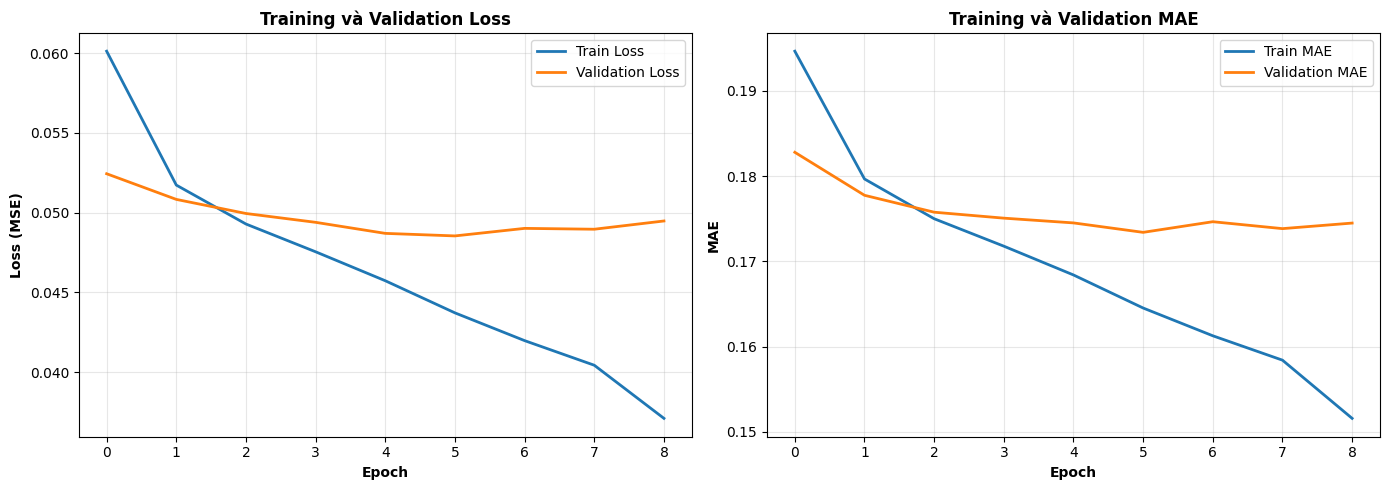

Đã lưu: figures/07_ncf_training_history.png


In [9]:
print("ĐÁNH GIÁ MODEL")

# Load best model without compilation
print("\nĐang load best model từ checkpoint...")
best_model = keras.models.load_model(
    '../models/neural_cf_model.h5',
    compile=False  # Không load compiled state
)

# Compile lại model
best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
print("Đã load và compile lại best model")

# Evaluate trên test set
print("\nĐánh giá trên Test Set:")
test_loss, test_mae = best_model.evaluate(
    [X_test_user, X_test_movie],
    y_test,
    batch_size=BATCH_SIZE,
    verbose=0
)

# Predict và tính RMSE
y_pred = best_model.predict([X_test_user, X_test_movie], batch_size=BATCH_SIZE, verbose=0)

# Denormalize predictions và ground truth
y_test_denorm = y_test * 4 + 1  # [0,1] → [1,5]
y_pred_denorm = y_pred.flatten() * 4 + 1

# Clip predictions về [1, 5]
y_pred_denorm = np.clip(y_pred_denorm, 1, 5)

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test_denorm, y_pred_denorm))
mae = mean_absolute_error(y_test_denorm, y_pred_denorm)

print(f"\nKết quả trên Test Set:")
print(f"   - RMSE: {rmse:.4f}")
print(f"   - MAE: {mae:.4f}")
print(f"   - MSE (normalized): {test_loss:.4f}")
print(f"   - MAE (normalized): {test_mae:.4f}")

# Plot training history
print("\nĐang vẽ training history...")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontweight='bold')
axes[0].set_title('Training và Validation Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('MAE', fontweight='bold')
axes[1].set_title('Training và Validation MAE', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/07_ncf_training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("Đã lưu: figures/07_ncf_training_history.png")

## BUILD RECOMMENDATION FUNCTION

In [10]:
print("XÂY DỰNG HÀM GỢI Ý")

def neural_recommend(user_id, n=10, verbose=True):
    """
    Gợi ý phim cho user dựa trên Neural Collaborative Filtering
    
    Parameters:
    -----------
    user_id : int
        ID của user cần gợi ý
    n : int
        Số lượng phim gợi ý (default=10)
    verbose : bool
        Hiển thị thông tin chi tiết
    
    Returns:
    --------
    DataFrame: Danh sách phim gợi ý
    """
    
    # Kiểm tra user có tồn tại không
    if user_id not in ratings['userId'].values:
        print(f"User ID {user_id} không tồn tại trong dataset")
        return None
    
    # Convert user_id sang user_idx
    try:
        user_idx = user_encoder.transform([user_id])[0]
    except:
        print(f"Không thể encode User ID {user_id}")
        return None
    
    # Lấy danh sách phim user đã rate
    user_ratings = ratings[ratings['userId'] == user_id]
    rated_movies = user_ratings['movieId'].values
    
    if verbose:
        print(f"\nUser ID: {user_id} (idx: {user_idx})")
        print(f"   - Đã đánh giá: {len(rated_movies)} phim")
        print(f"   - Rating trung bình: {user_ratings['rating'].mean():.2f}")
    
    # Lấy danh sách tất cả movies chưa rate
    all_movies = movies['movieId'].values
    unrated_movies = [m for m in all_movies if m not in rated_movies]
    
    if verbose:
        print(f"   - Số phim chưa rate: {len(unrated_movies)}")
    
    # Convert movie_ids sang movie_indices
    unrated_movie_indices = movie_encoder.transform(unrated_movies)
    
    # Predict rating cho tất cả unrated movies
    if verbose:
        print(f"\nĐang predict ratings cho {len(unrated_movies)} phim...")
    
    # Tạo input arrays
    user_array = np.full(len(unrated_movies), user_idx)
    movie_array = unrated_movie_indices
    
    # Predict
    predictions = best_model.predict(
        [user_array, movie_array],
        batch_size=1024,
        verbose=0
    )
    
    # Denormalize predictions
    predictions = predictions.flatten() * 4 + 1  # [0,1] → [1,5]
    predictions = np.clip(predictions, 1, 5)
    
    # Create DataFrame
    pred_df = pd.DataFrame({
        'movieId': unrated_movies,
        'predicted_rating': predictions
    })
    
    # Sort và lấy top N
    pred_df = pred_df.sort_values('predicted_rating', ascending=False).head(n)
    
    # Merge với thông tin phim
    recommendations = pred_df.merge(
        movies[['movieId', 'title_clean', 'genres', 'rating_avg', 'rating_count']],
        on='movieId'
    )
    recommendations['rank'] = range(1, len(recommendations) + 1)
    
    # Sắp xếp columns
    result_cols = ['rank', 'movieId', 'title_clean', 'genres',
                   'predicted_rating', 'rating_avg', 'rating_count']
    recommendations = recommendations[result_cols]
    
    if verbose:
        print(f"\nTop {n} phim gợi ý cho User {user_id}:")
        print("-" * 110)
        for _, row in recommendations.iterrows():
            print(f"#{row['rank']:<2} | {row['title_clean']:<35} | {row['genres']:<25} | "
                  f"Pred: {row['predicted_rating']:.2f} | Avg: {row['rating_avg']:.2f}")
    
    return recommendations


def neural_recommend_for_new_user(favorite_movies, n=10, verbose=True):
    """
    Gợi ý phim cho user mới (Cold Start) - Simplified version
    
    Parameters:
    -----------
    favorite_movies : list of tuples
        List các (movie_id, rating) của user
        Example: [(1, 5), (50, 4), (260, 5)]
    n : int
        Số lượng phim gợi ý
    verbose : bool
        Hiển thị thông tin chi tiết
    
    Returns:
    --------
    DataFrame: Danh sách phim gợi ý (dựa trên average của similar users)
    """
    
    if verbose:
        print(f"\nUser mới với {len(favorite_movies)} phim yêu thích")
        print("NCF cần retrain để handle user mới tốt nhất")
        print("Đề xuất: Dùng Content-Based hoặc Hybrid cho cold start\n")
    
    # Tìm users tương tự dựa trên favorite movies
    similar_users = []
    
    for movie_id, rating in favorite_movies:
        # Tìm users đã rate phim này với rating tương tự
        similar_ratings = ratings[
            (ratings['movieId'] == movie_id) &
            (ratings['rating'] >= rating - 0.5) &
            (ratings['rating'] <= rating + 0.5)
        ]
        similar_users.extend(similar_ratings['userId'].values)
    
    if len(similar_users) == 0:
        print("Không tìm thấy users tương tự")
        return None
    
    # Lấy top users tương tự
    from collections import Counter
    top_similar_users = [u for u, _ in Counter(similar_users).most_common(10)]
    
    if verbose:
        print(f"Tìm thấy {len(top_similar_users)} users tương tự")
    
    # Aggregate recommendations từ similar users
    all_recommendations = []
    
    for user_id in top_similar_users:
        recs = neural_recommend(user_id, n=n*2, verbose=False)
        if recs is not None:
            all_recommendations.append(recs)
    
    if len(all_recommendations) == 0:
        print("Không thể tạo recommendations")
        return None
    
    # Merge và aggregate
    combined = pd.concat(all_recommendations)
    
    # Remove favorite movies
    favorite_movie_ids = [m for m, _ in favorite_movies]
    combined = combined[~combined['movieId'].isin(favorite_movie_ids)]
    
    # Group by movie và aggregate
    final_recs = combined.groupby('movieId').agg({
        'title_clean': 'first',
        'genres': 'first',
        'predicted_rating': 'mean',
        'rating_avg': 'first',
        'rating_count': 'first'
    }).reset_index()
    
    final_recs = final_recs.sort_values('predicted_rating', ascending=False).head(n)
    final_recs['rank'] = range(1, len(final_recs) + 1)
    
    result_cols = ['rank', 'movieId', 'title_clean', 'genres',
                   'predicted_rating', 'rating_avg', 'rating_count']
    final_recs = final_recs[result_cols]
    
    if verbose:
        print(f"\nTop {n} phim gợi ý (dựa trên similar users):")
        print("-" * 110)
        for _, row in final_recs.iterrows():
            print(f"#{row['rank']:<2} | {row['title_clean']:<35} | {row['genres']:<25} | "
                  f"Pred: {row['predicted_rating']:.2f} | Avg: {row['rating_avg']:.2f}")
    
    return final_recs


print("Đã tạo 2 functions:")
print("   1. neural_recommend(user_id, n=10)")
print("   2. neural_recommend_for_new_user(favorite_movies, n=10)")

XÂY DỰNG HÀM GỢI Ý
Đã tạo 2 functions:
   1. neural_recommend(user_id, n=10)
   2. neural_recommend_for_new_user(favorite_movies, n=10)


## TEST RECOMMENDATION FUNCTIONS

In [11]:
print("KIỂM TRA HÀM GỢI Ý")
# TEST 1: Gợi ý cho user có sẵn
print("TEST 1: GỢI Ý CHO USER CÓ SẴN")

# Lấy một user ngẫu nhiên
active_users = ratings['userId'].value_counts()
test_user_id = active_users[active_users > 50].sample(1).index[0]

print(f"\nTest với User ID: {test_user_id}")
recs_1 = neural_recommend(test_user_id, n=10, verbose=True)

# Hiển thị phim user đã rate
print(f"\nMột số phim user đã rate (để tham khảo):")
user_rated = ratings[ratings['userId'] == test_user_id].merge(
    movies[['movieId', 'title_clean', 'genres']], on='movieId'
).sort_values('rating', ascending=False).head(5)

for _, row in user_rated.iterrows():
    print(f"{row['rating']:.1f} | {row['title_clean']:<40} | {row['genres']}")

# TEST 2: Gợi ý cho user mới
print("TEST 2: GỜI Ý CHO USER MỚI (COLD START)")

favorite_movies = [
    (1, 5),    # Toy Story
    (260, 4),  # Star Wars
    (1196, 5)  # Star Wars: Empire Strikes Back
]

print(f"\nUser mới yêu thích:")
for movie_id, rating in favorite_movies:
    movie_info = movies[movies['movieId'] == movie_id].iloc[0]
    print(f"{rating} | {movie_info['title_clean']} ({movie_info['genres']})")

recs_2 = neural_recommend_for_new_user(favorite_movies, n=10, verbose=True)

KIỂM TRA HÀM GỢI Ý
TEST 1: GỢI Ý CHO USER CÓ SẴN

Test với User ID: 1475

User ID: 1475 (idx: 1474)
   - Đã đánh giá: 79 phim
   - Rating trung bình: 3.90
   - Số phim chưa rate: 3337

Đang predict ratings cho 3337 phim...

Top 10 phim gợi ý cho User 1475:
--------------------------------------------------------------------------------------------------------------
#1  | Lamerica                            | Drama                     | Pred: 5.00 | Avg: 4.75
#2  | Message to Love: The Isle of Wight Festival | Documentary               | Pred: 4.93 | Avg: 4.00
#3  | Citizen Kane                        | Drama                     | Pred: 4.91 | Avg: 4.39
#4  | Apple, The (Sib)                    | Drama                     | Pred: 4.91 | Avg: 4.67
#5  | Sunset Blvd. (a.k.a. Sunset Boulevard) | Film-Noir                 | Pred: 4.88 | Avg: 4.49
#6  | Nights of Cabiria (Le Notti di Cabiria) | Drama                     | Pred: 4.88 | Avg: 4.21
#7  | Seven Chances                       | Com

## LƯU MODEL VÀ ARTIFACTS

In [13]:
print("LƯU MODEL VÀ ARTIFACTS")

# Model đã được save trong checkpoint, chỉ cần save encoders
print("\nĐang lưu encoders và training info...")

# Save encoders
with open('../models/neural_cf_user_encoder.pkl', 'wb') as f:
    pickle.dump(user_encoder, f)
print("Đã lưu: models/neural_cf_user_encoder.pkl")

with open('../models/neural_cf_movie_encoder.pkl', 'wb') as f:
    pickle.dump(movie_encoder, f)
print("Đã lưu: models/neural_cf_movie_encoder.pkl")

# Save training info
training_info = {
    'n_users': n_users,
    'n_movies': n_movies,
    'embedding_dim': EMBEDDING_DIM,
    'dense_units': DENSE_UNITS,
    'epochs_trained': len(history.history['loss']),
    'best_epoch': np.argmin(history.history['val_loss']) + 1,
    'final_train_loss': history.history['loss'][-1],
    'final_val_loss': history.history['val_loss'][-1],
    'test_rmse': rmse,
    'test_mae': mae,
    'total_params': total_params
}

with open('../models/neural_cf_training_info.pkl', 'wb') as f:
    pickle.dump(training_info, f)
print("Đã lưu: models/neural_cf_training_info.pkl")

# Save history
history_df = pd.DataFrame(history.history)
history_df.to_csv('../models/neural_cf_history.csv', index=False)
print("Đã lưu: models/neural_cf_history.csv")

LƯU MODEL VÀ ARTIFACTS

Đang lưu encoders và training info...
Đã lưu: models/neural_cf_user_encoder.pkl
Đã lưu: models/neural_cf_movie_encoder.pkl
Đã lưu: models/neural_cf_training_info.pkl
Đã lưu: models/neural_cf_history.csv


## TỔNG KẾT

In [15]:
print("TASK 6 HOÀN THÀNH!")

print("\nChecklist:")
print("Chuẩn bị data (convert IDs, normalize ratings)")
print("Build Neural Network (Embedding + Dense layers)")
print("Train model với callbacks (EarlyStopping, Checkpoint)")
print("Evaluate trên test set")
print("Build recommendation functions")
print("Test với nhiều trường hợp")
print("Lưu model và artifacts")

print("\nModel Architecture:")
print(f"User Embedding: {EMBEDDING_DIM} dimensions")
print(f"Movie Embedding: {EMBEDDING_DIM} dimensions")
print(f"Dense layers: {' → '.join(map(str, DENSE_UNITS))}")
print(f"Total parameters: {total_params:,}")

print("\nModel Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Best epoch: {np.argmin(history.history['val_loss']) + 1}")

print("\nOutput files:")
print("  - models/neural_cf_model.h5")
print("  - models/neural_cf_user_encoder.pkl")
print("  - models/neural_cf_movie_encoder.pkl")
print("  - models/neural_cf_training_info.pkl")
print("  - models/neural_cf_history.csv")
print("  - figures/07_ncf_training_history.png")

print("\nFunctions available:")
print("  - neural_recommend(user_id, n=10)")
print("  - neural_recommend_for_new_user(favorite_movies, n=10)")



TASK 6 HOÀN THÀNH!

Checklist:
Chuẩn bị data (convert IDs, normalize ratings)
Build Neural Network (Embedding + Dense layers)
Train model với callbacks (EarlyStopping, Checkpoint)
Evaluate trên test set
Build recommendation functions
Test với nhiều trường hợp
Lưu model và artifacts

Model Architecture:
User Embedding: 50 dimensions
Movie Embedding: 50 dimensions
Dense layers: 256 → 128 → 64
Total parameters: 554,373

Model Performance:
RMSE: 0.8849
MAE: 0.6969
Epochs trained: 9
Best epoch: 6

Output files:
  - models/neural_cf_model.h5
  - models/neural_cf_user_encoder.pkl
  - models/neural_cf_movie_encoder.pkl
  - models/neural_cf_training_info.pkl
  - models/neural_cf_history.csv
  - figures/07_ncf_training_history.png

Functions available:
  - neural_recommend(user_id, n=10)
  - neural_recommend_for_new_user(favorite_movies, n=10)
